<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Indep_t_test_Infant_walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
Researchers wished to know if they could conclude that two populations (India & USA) of infants differ with respect to mean age at which they walked alone. The data were collected in ages in months. [Data: Infant_walk.xlsx]

# Import necessary packages

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Mounting Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Read data

In [ ]:
# Reading the data

df = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/Infant_walk.xlsx')

# Exploratory Analysis

In [ ]:
df.columns

Index(['Country', 'Age'], dtype='object')

In [ ]:
df.head()                                   # Viewing first few observations of the data

,Country,Age
0,India,9.50
1,India,10.50
2,India,9.00
3,India,9.75
4,India,10.00


In [ ]:
df.describe()                               # Descriptive statistics

,Age
count,32.000000
mean,11.273438
std,1.449916
min,9.000000
25%,10.000000
50%,11.000000
75%,12.125000
max,13.750000


<Axes: title={'center': 'Age'}, xlabel='Country'>

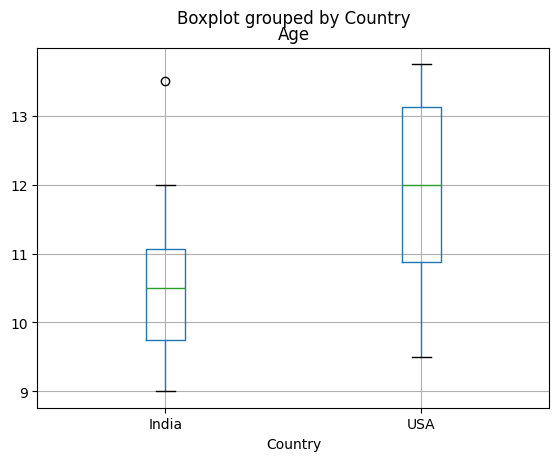

In [ ]:
df.boxplot(by ='Country', column =['Age'])  # Box-plot

# Normality test using Shapiro test

In [ ]:
Shapiro1 = stats.shapiro(df.Age[df.Country == 'India'])
print("Shapiro-Wilk test for Country India:", Shapiro1)

Shapiro-Wilk test for Country India: ShapiroResult(statistic=np.float64(0.9347956364031493), pvalue=np.float64(0.29006262763861845))


In [ ]:
Shapiro2 = stats.shapiro(df.Age[df.Country == 'USA'])
print("Shapiro-Wilk test for Country USA:", Shapiro2)

Shapiro-Wilk test for Country USA: ShapiroResult(statistic=np.float64(0.9099498975800483), pvalue=np.float64(0.116154468407907))


# Normality check using Q-Q plot

In [ ]:
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

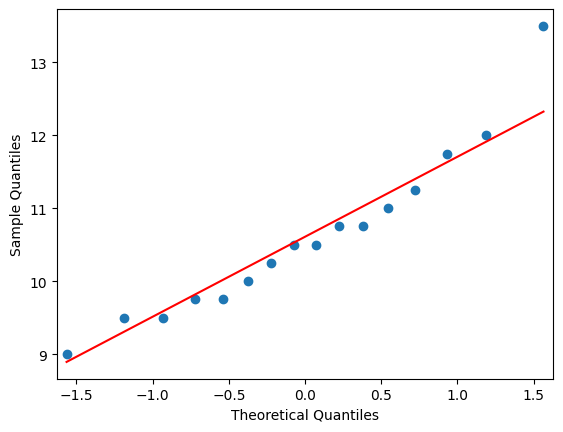

In [ ]:
qqplot(es.loc[es['Country'] == 'India', 'Age'], line='s')
plt.show()

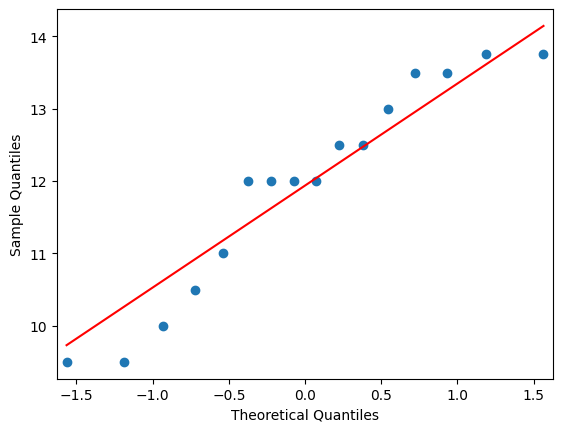

In [ ]:
qqplot(es.loc[es['Country'] == 'USA', 'Age'], line='s')
plt.show()


## Testing Equality of Variances

In [ ]:
# Levene test using Center as Mean
stats.levene(df.Age[df.Country == 'India'],df.Age[df.Country == 'USA'],center='mean')

LeveneResult(statistic=np.float64(1.2120909129652273), pvalue=np.float64(0.2796738678725949))

# Independent t test

In [ ]:
res = stats.ttest_ind(df.Age[df.Country == 'India'],df.Age[df.Country == 'USA'],equal_var=True,
  alternative='two-sided')
res

TtestResult(statistic=np.float64(-2.879454019601354), pvalue=np.float64(0.0072813294917748), df=np.float64(30.0))

In [ ]:
print("Average performance of INDIA Country:",(df.Age[df.Country == 'India']).mean())
print("Average performance of USA Country:",(df.Age[df.Country == 'USA']).mean())

Average performance of INDIA Country: 10.609375
Average performance of USA Country: 11.9375
